[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/17_pytorch/51_training_neural_networks.ipynb)

# 📓 Notebook 51 — Training Neural Networks Well

> **Module:** Deep Learning with PyTorch (Module 17) · **Estimated time:** ~70 minutes · **Difficulty:** Intermediate → Advanced

NB 50 gave you the five-step loop, and it *worked* — but "the loss went down" is a low bar. A network with 321 free parameters (let alone 321 million) will happily **memorise** your training set and call it learning; your job as its trainer is to catch that, stop it, and squeeze out genuine generalisation. This lesson is the craft: everything that separates a loop that runs from a model you'd let near production.

We stay on the SaaS churn data the whole way and upgrade the loop piece by piece: **mini-batches** (`Dataset`/`DataLoader`), the **two-curve diagnostic** that makes overfitting visible, the three standard treatments (**dropout, weight decay, early stopping**), **learning-rate schedules**, **saving/loading** models properly, **reproducibility**, and a clinic on the **four classic bugs** — each one demonstrated live, not just described.

> 🧪 **Everything here runs 100% offline.** PyTorch is a local library — no key, no network — and every model trains on CPU in seconds. Colab has torch preinstalled; locally, the setup cell prints the one-line install. Without torch, runtime cells check `HAS_TORCH` and skip gracefully.

> 🧭 **The mental model for the whole notebook.** *Capacity is a loan; the validation curve is the repayment schedule.* The training loss only tells you the model can fit what it has **seen** — every real decision (how long to train, how big, how regularised) must be made against data it has **not** seen. Two curves, train and validation, one gap between them: the whole craft of training is keeping that gap honest.

## ✅ Prerequisites

- **NB 50 (PyTorch fundamentals)** — tensors, autograd, `nn.Module`, the five-step loop, `BCEWithLogitsLoss`. Essential; we build directly on its churn classifier.
- **NB 15 (model evaluation)** — train/validation/test discipline and "never tune on the test set". This lesson is that discipline, applied to deep learning.
- **NB 16 (feature engineering)** — the golden rule (fit transforms on train only) applies verbatim.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Batch data with **`TensorDataset` + `DataLoader`** and explain what mini-batches buy (memory, speed, and a little useful noise).
2. Split **train / validation / test** correctly, plot the **two-curve diagnostic**, and read overfitting off it at a glance.
3. Apply the three standard treatments — **dropout**, **weight decay**, **early stopping** (with patience and best-weight restore) — and know what each one actually does.
4. Use **learning-rate schedules** (`StepLR`, `ReduceLROnPlateau`) instead of hand-tuning a single lr.
5. **Save and load** models the right way (`state_dict`, `map_location`, `eval()`), including the save-the-best-checkpoint pattern.
6. Write **reproducible, device-agnostic** training code (seeds; the `.to(device)` pattern that runs unchanged on CPU, CUDA or Apple MPS).
7. Recognise and fix the **four classic bugs**: exploding/NaN loss, a frozen loss, silent shape broadcasting, and forgotten `train()`/`eval()` modes.

## 1. Setup — data with a proper three-way split

Same synthetic SaaS customers as NB 14/15/50 — but this time split **three ways**. NB 15's rule was "never tune on the test set"; deep learning multiplies the number of knobs you'll be tempted to tune (width, dropout, epochs, lr, batch size…), so the **validation set** does all that dial-turning and the **test set** stays in the vault until the very end.

```text
600 customers ──▶ 60% train (fit weights) · 20% validation (turn dials) · 20% test (open once, at the end)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
    torch.manual_seed(RANDOM_STATE)
    print(f"PyTorch {torch.__version__} — CPU is plenty for everything below.")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)
    print("Install with:  pip install torch --index-url https://download.pytorch.org/whl/cpu")

/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTorch 2.12.0 — CPU is plenty for everything below.


In [2]:
# Rebuild the NB 14/15/50 churn dataset (same seed -> same 600 customers)
rng = np.random.default_rng(RANDOM_STATE)
n = 600
mrr_eur         = rng.lognormal(mean=6.5, sigma=0.7, size=n).clip(50, 50_000)
months_active   = rng.integers(1, 60, size=n)
support_tickets = rng.poisson(lam=2.5, size=n)
plan            = rng.choice(["Free", "Standard", "Premium", "Enterprise"],
                             size=n, p=[0.15, 0.45, 0.30, 0.10])
last_login_days = rng.integers(0, 90, size=n)
plan_adj = np.array([{"Free": -0.45, "Standard": 0.0, "Premium": 0.15, "Enterprise": 0.35}[p]
                     for p in plan])
happiness = (-0.40*(support_tickets-2.5)/2.0 - 0.80*(last_login_days-45)/30.0
             + 0.35*(np.log1p(mrr_eur)-6.5)/1.5 + 0.30*(months_active-30)/20.0
             + plan_adj + rng.normal(0, 0.30, n))
nps = (40 + 35*happiness + rng.normal(0, 8, n)).clip(-100, 100)
churned = (rng.random(n) < 1/(1+np.exp(-(-1.6 - 2.5*happiness)))).astype(int)
churn_df = pd.DataFrame({"mrr_eur": mrr_eur, "months_active": months_active,
                         "support_tickets": support_tickets, "nps": nps, "plan": plan,
                         "last_login_days": last_login_days, "churned": churned})

# Features -> three-way split -> scale (fit on TRAIN only, as always)
X_df = pd.get_dummies(churn_df.drop(columns=["churned"]), columns=["plan"], dtype=float)
y = churn_df["churned"].values.astype(np.float32)

X_trval, X_test, y_trval, y_test = train_test_split(X_df, y, test_size=0.20,
                                                    random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trval, y_trval, test_size=0.25,   # 0.25 × 0.8 = 0.2
                                                  random_state=RANDOM_STATE, stratify=y_trval)
scaler = StandardScaler().fit(X_train)
to32 = lambda a: a.astype(np.float32)
X_train, X_val, X_test = (to32(scaler.transform(d)) for d in (X_train, X_val, X_test))
print(f"train {X_train.shape} · val {X_val.shape} · test {X_test.shape}")

if HAS_TORCH:
    Xtr, ytr = torch.from_numpy(X_train), torch.from_numpy(y_train)
    Xva, yva = torch.from_numpy(X_val),   torch.from_numpy(y_val)
    Xte, yte = torch.from_numpy(X_test),  torch.from_numpy(y_test)
    N_FEATURES = Xtr.shape[1]

train (360, 9) · val (120, 9) · test (120, 9)


## 2. Mini-batches — `Dataset` and `DataLoader`

NB 50 trained **full-batch**: every epoch saw all rows at once. Fine for 600 rows; impossible for 600 million (they don't fit in memory) and, surprisingly, not even ideal when they *would* fit. Mini-batch training — updating after every 32–256 rows — buys three things:

1. **Memory.** Only one batch lives in RAM/GPU at a time. This is *the* enabler of large-scale DL.
2. **Speed of learning.** 12 updates per epoch instead of 1 — the model improves *during* the pass, not only after it.
3. **Useful noise.** Each batch gives a slightly different gradient. That jitter acts as a mild regulariser and helps escape flat spots.

The idiom is a pair of classes: a **`Dataset`** answers "give me row *i*" (`TensorDataset` zips feature and label tensors), and a **`DataLoader`** turns it into shuffled batches. Shuffling matters: without it, every epoch marches through identical batches in identical order, and any accidental ordering in your data (say, all Enterprise customers exported last) leaks into training.

In [3]:
if HAS_TORCH:
    train_ds = TensorDataset(Xtr, ytr)                       # zips X[i] with y[i]
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    print(f"{len(train_ds)} rows -> {len(train_loader)} batches of ≤64")
    xb, yb = next(iter(train_loader))                        # peek at one batch
    print("one batch:", xb.shape, yb.shape, "· churn rate in batch:", f"{yb.mean():.0%}")

360 rows -> 6 batches of ≤64
one batch: torch.Size([64, 9]) torch.Size([64]) · churn rate in batch: 34%


In [4]:
if HAS_TORCH:
    # The five-step loop, now with an inner batch loop — this is the FINAL form
    # of the training loop; everything later in the module decorates it.
    def make_model(hidden=32, p_drop=0.0):
        return nn.Sequential(
            nn.Linear(N_FEATURES, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, 1),
        )

    torch.manual_seed(RANDOM_STATE)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(30):
        model.train()
        for xb, yb in train_loader:                          # NEW: iterate batches
            loss = loss_fn(model(xb).squeeze(1), yb)
            loss.backward(); optimizer.step(); optimizer.zero_grad()
        if epoch % 10 == 0 or epoch == 29:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(Xva).squeeze(1), yva)
            print(f"epoch {epoch:2d}   last-batch loss {loss.item():.3f}   val loss {val_loss.item():.3f}")

epoch  0   last-batch loss 0.623   val loss 0.624
epoch 10   last-batch loss 0.463   val loss 0.449
epoch 20   last-batch loss 0.499   val loss 0.416
epoch 29   last-batch loss 0.596   val loss 0.423


> 💡 **Vocabulary check.** One **step** = one batch = one weight update. One **epoch** = one full pass over the training set (here: 6 steps of 64). Papers count steps; tutorials count epochs; you now speak both.

---

### ✋ Quick exercise (~2 min) — Count your steps

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Build a `DataLoader` over `train_ds` with `batch_size=32, shuffle=True`. Print (a) how many **steps per epoch** that gives (`len(loader)`), (b) the shape of the **last** batch (loop through and keep the final `xb`) — why isn't it 32 rows like the others?

In [5]:
# ✍️ Your turn 👇
if HAS_TORCH:
    loader32 = ...
    # print steps per epoch; loop to find the last batch's shape
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    loader32 = DataLoader(train_ds, batch_size=32, shuffle=True)
    print("steps per epoch:", len(loader32))          # ceil(360/32) = 12
    for xb, yb in loader32:
        pass
    print("last batch:", xb.shape)                    # 8 rows — the remainder
```

360 rows ÷ 32 = 11 full batches + a remainder of 8, so 12 steps and a short final batch. Losses like `BCEWithLogitsLoss` average per-row, so a short batch is harmless. (If a model genuinely needed fixed-size batches you'd pass `drop_last=True` — a detail worth knowing exists.)
</details>

## 3. The two-curve diagnostic — watch a network memorise

Time to *see* the enemy. We'll rig the fight in overfitting's favour — a **big** network (`hidden=256`, ~70k parameters) on a **tiny** training set (the first 100 rows) for many epochs — and log both losses every epoch. This is deliberately pathological; that's what makes the picture unforgettable.

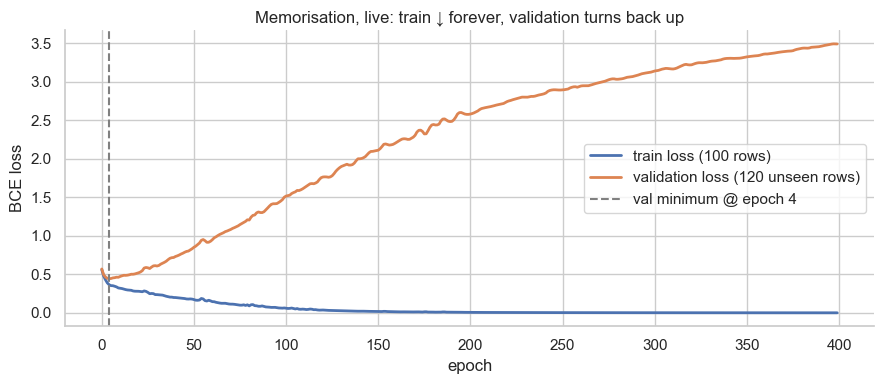

train loss end: 0.001   val loss end: 3.488   val loss best: 0.444 @ epoch 4


In [6]:
if HAS_TORCH:
    def train_curves(model, Xt, yt, Xv, yv, epochs=400, lr=1e-3, weight_decay=0.0, batch_size=32):
        """Train and return {'train': [...], 'val': [...]} epoch losses."""
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = nn.BCEWithLogitsLoss()
        loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
        hist = {"train": [], "val": []}
        for _ in range(epochs):
            model.train()
            for xb, yb in loader:
                loss = loss_fn(model(xb).squeeze(1), yb)
                loss.backward(); opt.step(); opt.zero_grad()
            model.eval()
            with torch.no_grad():                          # full-set losses for smooth curves
                hist["train"].append(loss_fn(model(Xt).squeeze(1), yt).item())
                hist["val"].append(loss_fn(model(Xv).squeeze(1), yv).item())
        return hist

    Xtiny, ytiny = Xtr[:100], ytr[:100]                    # a tiny training set: easy to memorise

    torch.manual_seed(RANDOM_STATE)
    glutton = make_model(hidden=256)                       # ~70k parameters vs. 100 rows
    hist_over = train_curves(glutton, Xtiny, ytiny, Xva, yva)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(hist_over["train"], lw=2, label="train loss (100 rows)")
    ax.plot(hist_over["val"], lw=2, label="validation loss (120 unseen rows)")
    best = int(np.argmin(hist_over["val"]))
    ax.axvline(best, color="grey", ls="--", lw=1.5, label=f"val minimum @ epoch {best}")
    ax.set(xlabel="epoch", ylabel="BCE loss", title="Memorisation, live: train ↓ forever, validation turns back up")
    ax.legend(); sns.despine(); fig.tight_layout(); plt.show()
    print(f"train loss end: {hist_over['train'][-1]:.3f}   val loss end: {hist_over['val'][-1]:.3f}"
          f"   val loss best: {min(hist_over['val']):.3f} @ epoch {best}")

Read the picture like an X-ray — this exact shape will greet you in every deep-learning project of your life:

- **Both curves fall together** at first: the model is learning real structure (happy phase).
- Then they **part company**: train keeps falling toward zero (memorising individual customers, noise and all) while validation bottoms out and **climbs**. Every epoch after the dashed line makes the model *worse at its job* while its train loss says it's doing great.
- The **gap** between the curves is the size of the lie the training loss is telling you.

Everything in §4–§5 is a way to move that dashed line later, lower the valley, or stop *at* it. And note what NB 15 would tell you: choosing the stopping epoch is *tuning*, so it must happen against **validation**, never test.

## 4. The treatments — dropout and weight decay

The two workhorse regularisers, one idea each:

| | What it does | Intuition | Where |
|---|---|---|---|
| **Dropout** | during *training only*, randomly zeroes each hidden unit with probability *p* | no unit can rely on a specific partner, so the net learns redundant, robust features — an ensemble of thinned networks | `nn.Dropout(p)` between layers |
| **Weight decay** | adds a pull toward zero on every weight at each update (L2) | big weights = confident, spiky fits; the pull keeps the function smooth — same soul as Ridge in NB 16 | `Adam(..., weight_decay=1e-3)` |

Dropout is also why `model.train()` / `model.eval()` stopped being optional: **train mode drops, eval mode doesn't.** Forget to switch and you'll either evaluate a randomly lobotomised model or train without your regulariser — §9 shows the symptom.

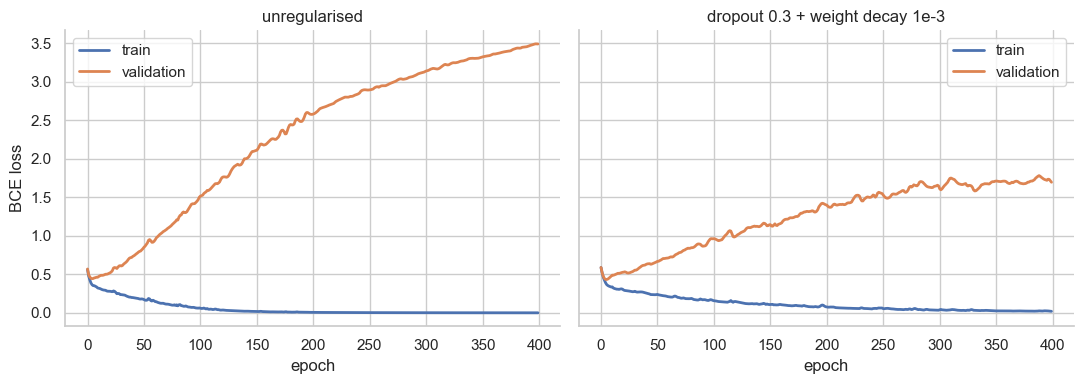

best val loss   unregularised: 0.444   regularised: 0.433


In [7]:
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    treated = make_model(hidden=256, p_drop=0.3)           # same glutton, medicated
    hist_reg = train_curves(treated, Xtiny, ytiny, Xva, yva, weight_decay=1e-3)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, h, title in [(axes[0], hist_over, "unregularised"),
                         (axes[1], hist_reg, "dropout 0.3 + weight decay 1e-3")]:
        ax.plot(h["train"], lw=2, label="train")
        ax.plot(h["val"], lw=2, label="validation")
        ax.set(xlabel="epoch", title=title)
        ax.legend()
    axes[0].set_ylabel("BCE loss")
    sns.despine(); fig.tight_layout(); plt.show()
    print(f"best val loss   unregularised: {min(hist_over['val']):.3f}"
          f"   regularised: {min(hist_reg['val']):.3f}")

The treated curves hug each other longer and the validation valley is flatter and (usually) lower — the network is being *forced* to learn only what generalises. Regularisation doesn't add intelligence; it removes the option to cheat.

> 💡 **Defaults that serve well:** dropout `p=0.1–0.3` on tabular MLPs, `weight_decay=1e-4–1e-2`, tuned on validation like everything else. And remember the cheapest regulariser of all is **more data** — always ask for it first.

---

### ✋ Quick exercise (~2 min) — The dropout dial

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Where's the sweet spot? For `p_drop` in `[0.0, 0.3, 0.6]`, train a fresh `make_model(hidden=256, p_drop=p)` on the tiny set (reuse `train_curves`, defaults, `torch.manual_seed(RANDOM_STATE)` before each) and print the **best validation loss** for each. Too little, too much, just right?

In [8]:
# ✍️ Your turn 👇
if HAS_TORCH:
    for p in [0.0, 0.3, 0.6]:
        ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    for p in [0.0, 0.3, 0.6]:
        torch.manual_seed(RANDOM_STATE)
        m = make_model(hidden=256, p_drop=p)
        h = train_curves(m, Xtiny, ytiny, Xva, yva)
        print(f"p_drop={p:.1f}   best val loss {min(h['val']):.3f}")
```

Typically `0.3` edges out `0.0` (less memorisation) *and* `0.6` (so much dropping that the net can barely learn the signal) — regularisation is a dial, not a switch, and **validation loss is the dial's readout**. Your exact numbers may shuffle slightly; DataLoader shuffling keeps its own randomness even with the seed fixed. If they do, that's your first taste of run-to-run variance — §8 tames it.
</details>

## 5. Early stopping — quit while you're ahead

The two-curve plot begs an obvious move: **stop training when validation stops improving.** That's early stopping — the cheapest regulariser after more data, and the standard shape is:

- track the best validation loss so far, and **snapshot the weights** whenever it improves;
- if it hasn't improved for `patience` consecutive epochs, stop;
- **restore the snapshot** — you keep the model from the valley, not from wherever you stopped.

The snapshot uses `model.state_dict()` — a dict of all weight tensors (our save/load workhorse in §7).

In [9]:
if HAS_TORCH:
    import copy

    def fit_early_stopping(model, Xt, yt, Xv, yv, max_epochs=400, lr=1e-3,
                           weight_decay=1e-3, patience=25, batch_size=32, verbose=True):
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = nn.BCEWithLogitsLoss()
        loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
        best_val, best_state, since_best = float("inf"), None, 0
        hist = {"train": [], "val": []}
        for epoch in range(max_epochs):
            model.train()
            for xb, yb in loader:
                loss = loss_fn(model(xb).squeeze(1), yb)
                loss.backward(); opt.step(); opt.zero_grad()
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(Xv).squeeze(1), yv).item()
                hist["train"].append(loss_fn(model(Xt).squeeze(1), yt).item())
            hist["val"].append(val_loss)
            if val_loss < best_val:                                 # new valley floor
                best_val, since_best = val_loss, 0
                best_state = copy.deepcopy(model.state_dict())      # snapshot the weights
            else:
                since_best += 1
                if since_best >= patience:                          # patience exhausted
                    if verbose:
                        print(f"early stop at epoch {epoch} — no val improvement for {patience} epochs")
                    break
        model.load_state_dict(best_state)                           # rewind to the valley
        return hist, best_val

    torch.manual_seed(RANDOM_STATE)
    stopped = make_model(hidden=256, p_drop=0.3)
    hist_es, best_val = fit_early_stopping(stopped, Xtiny, ytiny, Xva, yva)
    print(f"kept the weights from val loss {best_val:.3f} "
          f"(trained {len(hist_es['val'])} epochs instead of 400)")

early stop at epoch 30 — no val improvement for 25 epochs
kept the weights from val loss 0.433 (trained 31 epochs instead of 400)


---

### ✋ Quick exercise (~2 min) — How patient is patient enough?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Patience trades compute for a chance the valley wasn't the last dip. Run `fit_early_stopping` (fresh `make_model(hidden=256, p_drop=0.3)`, `torch.manual_seed(RANDOM_STATE)`, `verbose=False`) with `patience` in `[5, 25, 100]` and print, for each: the number of epochs actually trained (`len(hist["val"])`) and the best validation loss. What does too-little patience cost?

In [10]:
# ✍️ Your turn 👇
if HAS_TORCH:
    for patience in [5, 25, 100]:
        ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    for patience in [5, 25, 100]:
        torch.manual_seed(RANDOM_STATE)
        m = make_model(hidden=256, p_drop=0.3)
        h, bv = fit_early_stopping(m, Xtiny, ytiny, Xva, yva, patience=patience, verbose=False)
        print(f"patience={patience:<4}  stopped after {len(h['val']):3d} epochs   best val {bv:.3f}")
```

`patience=5` bails at the first wobble — validation loss is noisy, and a couple of flat epochs isn't proof the valley has passed — so it often keeps a slightly worse model. `patience=100` almost never triggers (you pay full compute). `~25` is the workaday compromise: enough patience to ride out noise, small enough to actually save time. Since best-weight *restore* means extra epochs never hurt the kept model, patience only costs compute — so err generous.
</details>

## 6. Learning-rate schedules — stop hand-tuning one number

NB 50's stretch B showed lr regimes: too small crawls, too big overshoots. The professional answer isn't a better single number — it's a **schedule**: start big (cover ground), end small (settle into the valley floor). Two you'll actually use:

| Scheduler | Policy | When |
|---|---|---|
| `StepLR(opt, step_size=50, gamma=0.5)` | halve the lr every 50 epochs, on a timer | simple, predictable baselines |
| `ReduceLROnPlateau(opt, factor=0.5, patience=10)` | halve the lr when **validation loss stalls** | the adaptive default — reacts to the actual curve |

One habit: call `scheduler.step()` once per **epoch** (`ReduceLROnPlateau` takes the validation loss as its argument — it's watching for stalls).

/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_43190/3610117760.py:8: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


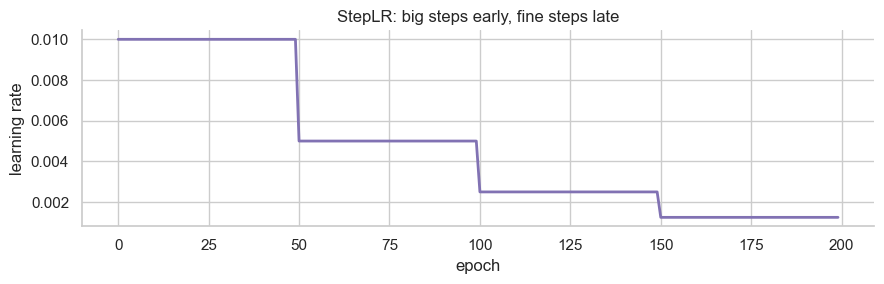

In [11]:
if HAS_TORCH:
    # What a schedule looks like, before we trust one with training:
    dummy_opt = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=0.01)
    sched = torch.optim.lr_scheduler.StepLR(dummy_opt, step_size=50, gamma=0.5)
    lrs = []
    for _ in range(200):
        lrs.append(dummy_opt.param_groups[0]["lr"])
        sched.step()
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(lrs, lw=2, color="#8172B3")
    ax.set(xlabel="epoch", ylabel="learning rate", title="StepLR: big steps early, fine steps late")
    sns.despine(); fig.tight_layout(); plt.show()

In [12]:
if HAS_TORCH:
    # ReduceLROnPlateau in a real loop — watch it cut the lr when val loss stalls
    torch.manual_seed(RANDOM_STATE)
    model = make_model(p_drop=0.2)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=10)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    last_lr = opt.param_groups[0]["lr"]
    for epoch in range(120):
        model.train()
        for xb, yb in loader:
            loss = loss_fn(model(xb).squeeze(1), yb)
            loss.backward(); opt.step(); opt.zero_grad()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xva).squeeze(1), yva).item()
        scheduler.step(val_loss)                              # <- feed it the val loss
        lr_now = opt.param_groups[0]["lr"]
        if lr_now != last_lr:
            print(f"epoch {epoch:3d}   val loss stalled -> lr cut to {lr_now:g}")
            last_lr = lr_now
    print(f"final: val loss {val_loss:.3f}, lr {lr_now:g} (started at 0.01)")

epoch  13   val loss stalled -> lr cut to 0.005
epoch  24   val loss stalled -> lr cut to 0.0025
epoch  35   val loss stalled -> lr cut to 0.00125
epoch  46   val loss stalled -> lr cut to 0.000625
epoch  57   val loss stalled -> lr cut to 0.0003125


epoch  68   val loss stalled -> lr cut to 0.00015625
epoch  79   val loss stalled -> lr cut to 7.8125e-05
epoch  90   val loss stalled -> lr cut to 3.90625e-05
epoch 101   val loss stalled -> lr cut to 1.95313e-05
epoch 112   val loss stalled -> lr cut to 9.76563e-06


final: val loss 0.503, lr 9.76563e-06 (started at 0.01)


## 7. Saving and loading — `state_dict`, done right

A trained model you can't reload is a science-fair project. The PyTorch convention is to save the **`state_dict`** — just the weight tensors — *not* the pickled model object (which breaks the moment your class definition moves or changes):

```text
save:  torch.save(model.state_dict(), "churn_mlp.pt")
load:  model = make_model(...)                       # rebuild the architecture in code
       model.load_state_dict(torch.load("churn_mlp.pt", map_location="cpu"))
       model.eval()                                  # ALWAYS, before inference
```

`map_location="cpu"` makes a GPU-trained checkpoint load anywhere — the classic "trained on the big box, serving on a small one" move. And you already met the in-memory version: early stopping's snapshot/restore *is* this pattern without the file.

In [13]:
if HAS_TORCH:
    from pathlib import Path

    ckpt = Path("churn_mlp.pt")
    torch.save(stopped.state_dict(), ckpt)                    # the early-stopped model from §5
    print(f"saved {ckpt} — {ckpt.stat().st_size/1024:.0f} KB of pure weights")

    reloaded = make_model(hidden=256, p_drop=0.3)             # same architecture, fresh weights
    reloaded.load_state_dict(torch.load(ckpt, map_location="cpu"))
    reloaded.eval()

    with torch.no_grad():
        p_orig = torch.sigmoid(stopped(Xva).squeeze(1))
        p_load = torch.sigmoid(reloaded(Xva).squeeze(1))
    print("identical predictions after reload:", bool(torch.allclose(p_orig, p_load)))

    ckpt.unlink()                                             # tidy up the demo file

saved churn_mlp.pt — 271 KB of pure weights
identical predictions after reload: True


> 💡 **The production checkpoint carries more than weights.** Real training jobs save a dict: `{"model": model.state_dict(), "optimizer": opt.state_dict(), "epoch": epoch, "val_loss": best_val}` — enough to *resume* training after a crash, not just to serve. Same `torch.save`, richer payload. NB 52 picks the story up at the serving end (export, TorchScript/ONNX).

## 8. Reproducibility and device-agnostic code

Two professional habits, three lines each.

**Seeds.** Weight init, dropout masks and `DataLoader` shuffling are all random — so two "identical" runs differ. For a *reproducible notebook*, pin them all: `torch.manual_seed` (+ `np.random.seed` for the data side). For an *honest experiment*, do the opposite on purpose: run 3–5 seeds and report mean ± std — if your improvement is smaller than the seed-to-seed spread, it isn't an improvement (NB 15's cross-validation instinct, reborn).

**Devices.** Write once, run on anything — CPU today, CUDA box tomorrow, Apple-silicon `mps` on your MacBook:

In [14]:
if HAS_TORCH:
    # THE pattern — memorise these three moves
    device = ("cuda" if torch.cuda.is_available()
              else "mps" if torch.backends.mps.is_available()
              else "cpu")
    model = make_model().to(device)                 # 1) model to device, once

    for xb, yb in DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True):
        xb, yb = xb.to(device), yb.to(device)       # 2) each batch to device
        logits = model(xb).squeeze(1)
        break                                       # (one step is enough for the demo)

    preds = logits.detach().cpu().numpy()           # 3) back to CPU before numpy/pandas
    print(f"ran on: {device} · logits shape {preds.shape} — same code on any machine")

ran on: mps · logits shape (64,) — same code on any machine


---

### ✋ Quick exercise (~2 min) — A device-proof `predict`

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Write `predict_proba(model, X_np)` that takes a trained model and a **NumPy** float32 array and returns churn probabilities as a NumPy array — safely, wherever the model lives: look up the model's device with `next(model.parameters()).device`, move the input there, run in `eval()` + `no_grad()`, apply `sigmoid`, and come back via `.cpu().numpy()`. Test it on `X_val` with the `stopped` model.

In [15]:
# ✍️ Your turn 👇
if HAS_TORCH:
    def predict_proba(model, X_np):
        ...
    # print(predict_proba(stopped, X_val)[:5].round(3))
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    def predict_proba(model, X_np):
        device = next(model.parameters()).device        # wherever the model lives
        model.eval()
        with torch.no_grad():
            x = torch.from_numpy(np.asarray(X_np, dtype=np.float32)).to(device)
            return torch.sigmoid(model(x).squeeze(1)).cpu().numpy()

    print(predict_proba(stopped, X_val)[:5].round(3))
```

This little function encodes the full inference liturgy — device lookup, `eval()`, `no_grad()`, sigmoid, back to CPU — and it's exactly the seam where PyTorch meets the pandas/sklearn world. NB 52 grows it into a complete sklearn-style wrapper class.
</details>

## 9. The bug clinic — four classics, live

Deep-learning bugs rarely crash; they *misbehave*. Here are the four you'll actually meet, each with its signature symptom — run the demos so the symptoms are burned in.

| # | Bug | Symptom | Fix |
|---|---|---|---|
| 1 | **Learning rate too high** (or unscaled inputs) | loss explodes → `inf` → `nan` | lower lr ×10; scale your features |
| 2 | **The loop is broken** (missing `zero_grad` / `step`, or lr=0) | loss frozen or drifting up | re-check the five steps, in order |
| 3 | **Silent shape broadcasting** | loss computes but is nonsense; a `UserWarning` you ignored | make target and prediction shapes match *exactly* |
| 4 | **Forgotten `train()`/`eval()`** | predictions differ run to run; val loss oddly bad or oddly noisy | `train()` to train, `eval()` (+ `no_grad`) to predict |

In [16]:
if HAS_TORCH:
    # BUG 1 — NaN loss: unscaled features (mrr_eur in the thousands!) + a hot lr.
    raw_mrr = torch.tensor(churn_df[["mrr_eur"]].to_numpy(np.float32))   # NOT scaled
    target = torch.tensor(churn_df["nps"].to_numpy(np.float32))

    torch.manual_seed(RANDOM_STATE)
    m = nn.Linear(1, 1)
    opt = torch.optim.SGD(m.parameters(), lr=0.1)
    for step in range(6):
        loss = nn.MSELoss()(m(raw_mrr).squeeze(1), target)
        loss.backward(); opt.step(); opt.zero_grad()
        print(f"step {step}   loss {loss.item():.3e}")
    print("-> exploding to inf within four steps (one more op and it's nan):")
    print("   gradients scale with the inputs, and mrr_eur is in the 1000s.")
    print("   Fix: StandardScaler (why every X in this module was scaled) and/or a much smaller lr.")

step 0   loss 5.866e+05
step 1   loss 2.790e+16
step 2   loss 1.330e+27
step 3   loss inf
step 4   loss inf
step 5   loss inf
-> exploding to inf within four steps (one more op and it's nan):
   gradients scale with the inputs, and mrr_eur is in the 1000s.
   Fix: StandardScaler (why every X in this module was scaled) and/or a much smaller lr.


In [17]:
if HAS_TORCH:
    # BUG 3 — silent broadcasting: prediction (n,1) vs target (n,) in MSELoss.
    import warnings
    pred_2d = torch.randn(360, 1)             # forgot .squeeze(1)
    target_1d = torch.randn(360)

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        wrong = nn.MSELoss()(pred_2d, target_1d)          # broadcasts (360,1)·(360,) -> (360,360)!
    right = nn.MSELoss()(pred_2d.squeeze(1), target_1d)
    print(f"wrong loss {wrong.item():.3f}   right loss {right.item():.3f}   (not even close)")
    print("PyTorch DID warn:", str(caught[0].message)[:88], "...")
    print("-> Treat that UserWarning as an error. One .squeeze(1) is the whole fix.")

wrong loss 1.874   right loss 1.648   (not even close)
PyTorch DID warn: Using a target size (torch.Size([360])) that is different to the input size (torch.Size( ...
-> Treat that UserWarning as an error. One .squeeze(1) is the whole fix.


In [18]:
if HAS_TORCH:
    # BUG 4 — forgotten eval(): dropout keeps firing at inference.
    torch.manual_seed(RANDOM_STATE)
    m = make_model(p_drop=0.5)

    m.train()                                              # WRONG mode for predictions
    with torch.no_grad():
        a = torch.sigmoid(m(Xva[:1])).item()
        b = torch.sigmoid(m(Xva[:1])).item()
    m.eval()                                               # right mode
    with torch.no_grad():
        c = torch.sigmoid(m(Xva[:1])).item()
        d = torch.sigmoid(m(Xva[:1])).item()
    print(f"train() mode, same customer twice: {a:.3f} vs {b:.3f}   <- a coin-flipping model!")
    print(f"eval()  mode, same customer twice: {c:.3f} vs {d:.3f}   <- deterministic, as it must be")

train() mode, same customer twice: 0.468 vs 0.446   <- a coin-flipping model!
eval()  mode, same customer twice: 0.441 vs 0.441   <- deterministic, as it must be


*(Bug 2 — the broken loop — starred as NB 50's debug-me: the missing `zero_grad`. You've already fixed it once; that's the point.)*

> 🧠 **The debugging order that saves afternoons:** loss `nan`? → scaling & lr. Loss frozen? → the five steps. Loss fine but metrics nonsense? → shapes. Metrics fine in training but flaky at inference? → modes. Four checks, thirty seconds each, and they cover a startling fraction of all deep-learning misery.

## 🧪 Practice exercises

These reuse the setup above (`Xtr/ytr`, `Xva/yva`, `make_model`, `train_curves`, `fit_early_stopping`, `predict_proba` from the checkpoint). Try each before opening the solution.

### Exercise 1 — ⭐ Batch size, timed

Train `make_model()` on the **full** training set for 40 epochs at `batch_size` ∈ `[16, 64, 360]` (that last one = full batch). For each: wrap the training in `time.perf_counter()` and print seconds taken and final validation loss (reuse `train_curves` with `epochs=40, batch_size=...`; fresh seed each time). Which is fastest per epoch, and why isn't wall-clock the whole story?

In [19]:
# Your code here  👇
if HAS_TORCH:
    import time
    for bs in [16, 64, 360]:
        ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    import time
    for bs in [16, 64, 360]:
        torch.manual_seed(RANDOM_STATE)
        m = make_model()
        t0 = time.perf_counter()
        h = train_curves(m, Xtr, ytr, Xva, yva, epochs=40, batch_size=bs)
        dt = time.perf_counter() - t0
        print(f"batch_size={bs:<4}  {dt:5.1f}s   final val loss {h['val'][-1]:.3f}")
```

Full batch (360) does the fewest updates per epoch, so each epoch is *cheapest* — but it also learns least per epoch (1 update vs 23 at batch 16), so it typically needs more epochs to reach the same loss. Small batches spend more wall-clock per epoch but arrive in fewer epochs. That's the trade: **updates per epoch vs. cost per epoch** — batch 32–128 is the tabular sweet spot, and on GPUs, throughput (rows/sec) tilts the math further.
</details>

### Exercise 2 — ⭐⭐ The weight-decay dial

Sweep `weight_decay` ∈ `[0, 1e-4, 1e-3, 1e-2, 1e-1]` on the **tiny** overfitting setup (`hidden=256`, `Xtiny/ytiny`, 400 epochs — i.e. exactly the §3 fight, treated with only weight decay). Print best validation loss per setting. Where does help turn into harm?

In [20]:
# Your code here  👇
if HAS_TORCH:
    for wd in [0, 1e-4, 1e-3, 1e-2, 1e-1]:
        ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    for wd in [0, 1e-4, 1e-3, 1e-2, 1e-1]:
        torch.manual_seed(RANDOM_STATE)
        m = make_model(hidden=256)
        h = train_curves(m, Xtiny, ytiny, Xva, yva, weight_decay=wd)
        print(f"weight_decay={wd:<7g} best val loss {min(h['val']):.3f}")
```

The pattern is a U: none → memorisation; a middling amount (`1e-3`-ish) → the best valley; `1e-1` → the pull-to-zero is so strong the model can't hold the real signal either (underfitting). Every regulariser has this U — which is why the dial is always set on **validation**, never by folklore.
</details>

### Exercise 3 — ⭐⭐ A reusable `EarlyStopper`

Extract §5's logic into a class you can drop into any loop:

```python
stopper = EarlyStopper(patience=25, min_delta=0.0)
for epoch ...:
    ...
    if stopper.step(val_loss, model):   # returns True when it's time to stop
        break
stopper.restore(model)                  # load the best snapshot back
```

`min_delta` means "an improvement smaller than this doesn't reset my patience." Implement it (track `best`, `since_best`, a `state_dict` snapshot) and prove it works by retraining the §3 glutton with it.

In [21]:
# Your code here  👇
if HAS_TORCH:
    class EarlyStopper:
        def __init__(self, patience=25, min_delta=0.0):
            ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    class EarlyStopper:
        def __init__(self, patience=25, min_delta=0.0):
            self.patience, self.min_delta = patience, min_delta
            self.best, self.since_best, self.best_state = float("inf"), 0, None

        def step(self, val_loss, model):
            if val_loss < self.best - self.min_delta:
                self.best, self.since_best = val_loss, 0
                self.best_state = copy.deepcopy(model.state_dict())
            else:
                self.since_best += 1
            return self.since_best >= self.patience

        def restore(self, model):
            if self.best_state is not None:
                model.load_state_dict(self.best_state)

    torch.manual_seed(RANDOM_STATE)
    m = make_model(hidden=256, p_drop=0.3)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(Xtiny, ytiny), batch_size=32, shuffle=True)
    stopper = EarlyStopper(patience=25)
    for epoch in range(400):
        m.train()
        for xb, yb in loader:
            loss = loss_fn(m(xb).squeeze(1), yb)
            loss.backward(); opt.step(); opt.zero_grad()
        m.eval()
        with torch.no_grad():
            vl = loss_fn(m(Xva).squeeze(1), yva).item()
        if stopper.step(vl, m):
            print(f"stopped at epoch {epoch}, best val {stopper.best:.3f}")
            break
    stopper.restore(m)
```

Separating the *policy* (when to stop, what to keep) from the *loop* is the design idea behind every training framework's "callback" — you've just written your first one.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

A colleague evaluates their dropout model like this and complains that "validation loss jumps around between reruns *of the same cell*, and it's worse than the train loss ever was." Run it, reproduce the wobble (run the loop twice!), name the two missing lines, and write the fixed version.

In [22]:
# 👇 Buggy on purpose — run it twice and watch the "validation loss" change between runs.
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    wobbly = make_model(p_drop=0.5)
    opt = torch.optim.Adam(wobbly.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
    for epoch in range(30):
        wobbly.train()
        for xb, yb in loader:
            loss = loss_fn(wobbly(xb).squeeze(1), yb)
            loss.backward(); opt.step(); opt.zero_grad()

    for run in [1, 2]:                     # "evaluate" twice — should be identical, isn't
        val_loss = loss_fn(wobbly(Xva).squeeze(1), yva)   # <- what's missing here?
        print(f"run {run}: validation loss {val_loss.item():.4f}")
else:
    print("PyTorch not available — skipping.")

run 1: validation loss 0.4336
run 2: validation loss 0.4839


<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    wobbly.eval()                                  # missing line 1 — switch dropout OFF
    with torch.no_grad():                          # missing line 2 — no graph at inference
        for run in [1, 2]:
            val_loss = loss_fn(wobbly(Xva).squeeze(1), yva)
            print(f"run {run}: validation loss {val_loss.item():.4f}")
```

The model was left in `train()` mode, so **dropout kept firing during evaluation**: each run zeroes a different random half of the hidden units — hence a different (and pessimistic) loss every time. `eval()` fixes the wobble; `no_grad()` fixes the silent cost you didn't see (autograd was recording a graph for an evaluation that will never call `backward()`, wasting memory). Bug 4 from the clinic, in the wild.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Gradient clipping

Cook up instability: train `make_model(hidden=256)` on `Xtr/ytr` with SGD at `lr=5.0` for 60 epochs (full-batch is fine) and print the loss every 10 — it should jump around or blow up. Then add **`torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)`** between `backward()` and `step()` and rerun. Clipping caps the *length* of the gradient vector while keeping its direction — the seatbelt that RNN and transformer training (appendix A2/A3) wears as standard equipment.

In [23]:
# Your code here  👇
if HAS_TORCH:
    for clipped in [False, True]:
        ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    for clipped in [False, True]:
        torch.manual_seed(RANDOM_STATE)
        m = make_model(hidden=256)
        opt = torch.optim.SGD(m.parameters(), lr=5.0)
        loss_fn = nn.BCEWithLogitsLoss()
        print("WITH clipping:" if clipped else "NO clipping:")
        for epoch in range(60):
            loss = loss_fn(m(Xtr).squeeze(1), ytr)
            loss.backward()
            if clipped:
                torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            opt.step(); opt.zero_grad()
            if epoch % 10 == 0:
                print(f"  epoch {epoch:2d}   loss {loss.item():9.3f}")
```

Unclipped, an absurd lr turns each step into a leap and the loss staggers (or hits `inf`). Clipped, the same lr behaves — steps keep their direction but never exceed length 1.0. Clipping doesn't fix a bad lr so much as make its worst case survivable; that's why it's non-negotiable in architectures whose gradients can spike (RNNs, transformers).
</details>

### Stretch exercise B — ⭐⭐⭐ Cross-validation for a network

A single validation split is one noisy opinion (NB 15's core complaint). Use `sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)` over the **train+val** rows (stack `Xtr`/`Xva` with `torch.cat`) to train five fresh `make_model(p_drop=0.2)` (60 epochs, batch 64) and collect the five fold ROC-AUCs (use `predict_proba` from the §8 checkpoint). Report mean ± std — and then say whether the §4 regularised model's single-split gain would survive this bar.

In [24]:
# Your code here  👇
if HAS_TORCH:
    from sklearn.model_selection import StratifiedKFold
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    from sklearn.model_selection import StratifiedKFold

    X_all = torch.cat([Xtr, Xva]).numpy()
    y_all = torch.cat([ytr, yva]).numpy()
    aucs = []
    for fold, (tr_idx, va_idx) in enumerate(
            StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_all, y_all)):
        torch.manual_seed(RANDOM_STATE + fold)
        m = make_model(p_drop=0.2)
        opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-3)
        loss_fn = nn.BCEWithLogitsLoss()
        loader = DataLoader(TensorDataset(torch.from_numpy(X_all[tr_idx]),
                                          torch.from_numpy(y_all[tr_idx])),
                            batch_size=64, shuffle=True)
        for _ in range(60):
            m.train()
            for xb, yb in loader:
                loss = loss_fn(m(xb).squeeze(1), yb)
                loss.backward(); opt.step(); opt.zero_grad()
        aucs.append(roc_auc_score(y_all[va_idx], predict_proba(m, X_all[va_idx])))
        print(f"fold {fold}: AUC {aucs[-1]:.3f}")
    print(f"\n5-fold AUC {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
```

The ± is the punchline: on 480 rows the fold-to-fold spread is typically a few hundredths of AUC — *bigger than most single-split "improvements" you'll be tempted to ship*. CV is rarer in deep learning than in classical ML (five trainings cost five× compute), but on small data it's the same honesty tool it always was. Note the vault stayed shut: `Xte` played no part.
</details>

### Stretch exercise C — ⭐⭐⭐ A custom `Dataset`

`TensorDataset` covers the easy case. Write `ChurnDataset(df, scaler=None)` — a `torch.utils.data.Dataset` subclass whose `__init__` does the one-hot + scaling (fitting the scaler if none is passed, reusing it otherwise: golden rule!), and whose `__getitem__(i)` returns `(features_tensor, label_tensor)` for one customer. Build a train instance and a val instance **that reuses the train scaler**, wrap them in `DataLoader`s, and run one epoch to prove it works. This is the shape every real project uses once data stops being one clean array — images on disk, rows in a database, text needing tokenisation.

In [25]:
# Your code here  👇
if HAS_TORCH:
    from torch.utils.data import Dataset

    class ChurnDataset(Dataset):
        def __init__(self, df, scaler=None):
            ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    from torch.utils.data import Dataset

    class ChurnDataset(Dataset):
        def __init__(self, df, scaler=None):
            X = pd.get_dummies(df.drop(columns=["churned"]), columns=["plan"], dtype=float)
            self.scaler = scaler or StandardScaler().fit(X)     # fit only if not given one
            self.X = torch.from_numpy(self.scaler.transform(X).astype(np.float32))
            self.y = torch.from_numpy(df["churned"].values.astype(np.float32))

        def __len__(self):
            return len(self.y)

        def __getitem__(self, i):
            return self.X[i], self.y[i]

    train_df, val_df = churn_df.iloc[:480], churn_df.iloc[480:]
    train_ds2 = ChurnDataset(train_df)                    # fits its own scaler
    val_ds2 = ChurnDataset(val_df, scaler=train_ds2.scaler)   # REUSES it — no leakage

    torch.manual_seed(RANDOM_STATE)
    m = make_model()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    for xb, yb in DataLoader(train_ds2, batch_size=64, shuffle=True):
        loss = loss_fn(m(xb).squeeze(1), yb)
        loss.backward(); opt.step(); opt.zero_grad()
    print(f"one epoch done · {len(train_ds2)} train rows · {len(val_ds2)} val rows · last loss {loss.item():.3f}")
```

Three methods — `__init__`, `__len__`, `__getitem__` — and `DataLoader` handles batching, shuffling and (with `num_workers`) parallel loading for free. The scaler handoff is the detail worth copying: the *Dataset owns the transform*, and validation explicitly borrows the train-fitted one.
</details>

### Stretch exercise D — ⭐⭐⭐ Optimizer bake-off

Same model, same data, three optimizers: plain `SGD(lr=0.01)`, `SGD(lr=0.01, momentum=0.9)`, and `Adam(lr=1e-3)`. Train each for 80 epochs on the full training set (fresh seed each; reuse `train_curves` — add an `optimizer` switch or inline the loop) and plot the three **validation** curves together. Momentum is the interesting one: each step is a running average of past gradients — a heavy ball rolling downhill instead of a hiker taking independent steps.

In [26]:
# Your code here  👇
if HAS_TORCH:
    curves = {}
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    def train_with(opt_name, epochs=80):
        torch.manual_seed(RANDOM_STATE)
        m = make_model()
        opt = {"sgd":      torch.optim.SGD(m.parameters(), lr=0.01),
               "momentum": torch.optim.SGD(m.parameters(), lr=0.01, momentum=0.9),
               "adam":     torch.optim.Adam(m.parameters(), lr=1e-3)}[opt_name]
        loss_fn = nn.BCEWithLogitsLoss()
        loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
        hist = []
        for _ in range(epochs):
            m.train()
            for xb, yb in loader:
                loss = loss_fn(m(xb).squeeze(1), yb)
                loss.backward(); opt.step(); opt.zero_grad()
            m.eval()
            with torch.no_grad():
                hist.append(loss_fn(m(Xva).squeeze(1), yva).item())
        return hist

    curves = {name: train_with(name) for name in ["sgd", "momentum", "adam"]}
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, h in curves.items():
        ax.plot(h, lw=2, label=name)
    ax.set(xlabel="epoch", ylabel="val BCE loss", title="Optimizer bake-off — same loop, different step rules")
    ax.legend(); sns.despine(); fig.tight_layout(); plt.show()
```

Typical result: plain SGD trails (small fixed steps), momentum closes most of the gap, Adam gets there fastest with zero tuning. That's why Adam (and its sibling AdamW — Adam with decoupled weight decay) is the modern default, with well-tuned SGD+momentum surviving mainly in vision folklore. The loop, as ever, never changed.
</details>

## 🎁 Bonus mini-project — A mini-`Trainer`

Assemble the whole lesson into one reusable class:

```python
trainer = Trainer(model, lr=1e-3, weight_decay=1e-3, patience=25, batch_size=64)
history = trainer.fit(Xtr, ytr, Xva, yva, max_epochs=400)   # batches, ReduceLROnPlateau,
proba   = trainer.predict_proba(X_test)                      # early stopping + best-restore
```

`fit` should: build the `DataLoader`, train with Adam + `ReduceLROnPlateau`, track train/val loss per epoch, early-stop with best-weight restore, and return the history. `predict_proba` should be device-safe (§8 checkpoint). Then: train it on the churn data, plot the curves — and, ceremonially, **open the vault**: report test-set ROC-AUC, once.

*You have now written, in miniature, what PyTorch Lightning's `Trainer` does — the framework that Module 10's DeepTab runs on. When you meet `trainer.fit(...)` there, you'll know exactly what's inside.*

In [27]:
# Your code here  👇
if HAS_TORCH:
    class Trainer:
        def __init__(self, model, lr=1e-3, weight_decay=1e-3, patience=25, batch_size=64):
            ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution sketch</b></summary>

```python
if HAS_TORCH:
    class Trainer:
        def __init__(self, model, lr=1e-3, weight_decay=1e-3, patience=25, batch_size=64):
            self.model = model
            self.opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            self.sched = torch.optim.lr_scheduler.ReduceLROnPlateau(self.opt, factor=0.5, patience=10)
            self.loss_fn = nn.BCEWithLogitsLoss()
            self.patience, self.batch_size = patience, batch_size

        def fit(self, Xt, yt, Xv, yv, max_epochs=400):
            loader = DataLoader(TensorDataset(Xt, yt), batch_size=self.batch_size, shuffle=True)
            best, since, best_state = float("inf"), 0, None
            hist = {"train": [], "val": []}
            for epoch in range(max_epochs):
                self.model.train()
                for xb, yb in loader:
                    loss = self.loss_fn(self.model(xb).squeeze(1), yb)
                    loss.backward(); self.opt.step(); self.opt.zero_grad()
                self.model.eval()
                with torch.no_grad():
                    hist["train"].append(self.loss_fn(self.model(Xt).squeeze(1), yt).item())
                    val = self.loss_fn(self.model(Xv).squeeze(1), yv).item()
                hist["val"].append(val)
                self.sched.step(val)
                if val < best:
                    best, since, best_state = val, 0, copy.deepcopy(self.model.state_dict())
                else:
                    since += 1
                    if since >= self.patience:
                        break
            self.model.load_state_dict(best_state)
            return hist

        def predict_proba(self, X_np):
            device = next(self.model.parameters()).device
            self.model.eval()
            with torch.no_grad():
                x = torch.from_numpy(np.asarray(X_np, dtype=np.float32)).to(device)
                return torch.sigmoid(self.model(x).squeeze(1)).cpu().numpy()

    torch.manual_seed(RANDOM_STATE)
    trainer = Trainer(make_model(p_drop=0.2))
    hist = trainer.fit(Xtr, ytr, Xva, yva)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(hist["train"], lw=2, label="train")
    ax.plot(hist["val"], lw=2, label="validation")
    ax.set(xlabel="epoch", ylabel="BCE loss", title=f"Trainer.fit — stopped after {len(hist['val'])} epochs")
    ax.legend(); sns.despine(); fig.tight_layout(); plt.show()

    # 🔓 The vault opens exactly once, at the very end:
    print(f"TEST ROC-AUC (first and only look): {roc_auc_score(y_test, trainer.predict_proba(X_test)):.3f}")
```

Every technique of the lesson lives in ~40 lines: batching, scheduling, early stopping with restore, device-safe inference — and the test set was touched exactly once, after every decision was already made. That last sentence is the habit that outlives any framework.
</details>

## 🧠 Key takeaways

- **Three-way split**: train fits weights, **validation turns every dial** (epochs, width, dropout, lr…), test is opened once at the end. Deep learning has more dials than classical ML — the discipline matters *more*, not less.
- **`Dataset` + `DataLoader`** turn data into shuffled mini-batches; one *step* per batch, one *epoch* per pass. Batches buy memory-scalability, faster learning per pass, and a little regularising noise.
- The **two-curve diagnostic** is your X-ray: curves parting = memorisation beginning. The gap is the lie the train loss tells.
- Treatments: **dropout** (train-time only — hence `train()`/`eval()`), **weight decay** (pull toward zero; Ridge's soul), **early stopping** (snapshot best, patience, restore). Each is a dial with a U-shaped response, read on validation.
- **Schedules beat a single lr**: `StepLR` on a timer, `ReduceLROnPlateau` on evidence.
- Save the **`state_dict`**, rebuild the architecture in code, `map_location="cpu"`, `eval()` before inference. Production checkpoints add optimizer state + epoch for resumability.
- **Seeds** make notebooks reproducible; multiple seeds make experiments honest. The 3-line **device pattern** (`model.to(device)`, batches `.to(device)`, results `.cpu().numpy()`) runs unchanged from laptop to GPU box.
- Bugs misbehave rather than crash: **nan → scaling/lr · frozen → the five steps · nonsense → shapes · flaky → modes.**

## ✅ Self-assessment

- [ ] Explain what a mini-batch buys and define step vs. epoch
- [ ] Build a `DataLoader` and write the batched five-step loop from memory
- [ ] Sketch the two-curve plot of an overfitting run and mark where to stop
- [ ] Say what dropout and weight decay each do — and why dropout needs `eval()`
- [ ] Implement early stopping with patience and best-weight restore
- [ ] Attach `ReduceLROnPlateau` and explain when it acts
- [ ] Save and reload a model via `state_dict` and prove predictions are identical
- [ ] Write device-agnostic training/inference code and pin seeds
- [ ] Diagnose: nan loss, frozen loss, silently-broadcast shapes, forgotten `eval()`

## 🚀 Next step

You can train networks honestly. **`52_pytorch_in_practice.ipynb`** makes them *useful on business data*: embeddings that turn categories into learned vectors, an honest bake-off against gradient boosting, a sklearn-style wrapper so your net drops into any pipeline — and the serving story (export, TorchScript/ONNX) that gets it out of the notebook.